In [1]:
import numpy as np
import pandas as pd
import numpy as np
import h5py
import glob
import os
import sklearn
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
from math import sqrt

# --- CONTROL VARIABLES: SET HOW MANY FILES TO USE ---
# For loading the tabular DataFrame (for Part 1: Preprocessing)
NUM_FILES_FOR_TABULAR_TRAIN = 26 # Max is 60 due to one corrupt file
NUM_FILES_FOR_TABULAR_VALIDATION = 27 # Max is 27

# For training the CNN with a generator (for Part 2: Model Development)
NUM_FILES_FOR_CNN_TRAIN = 26 # Max is 60
NUM_FILES_FOR_CNN_VALIDATION = 27 # Max is 27
# ---------------------------------------------------


# --- 1. SETUP: Find all files and filter out the bad one ---
print("--- Step 1: Finding all data files ---")
base_path = '/kaggle/input/iit-data/2. Dataset/'
file_to_skip = 'jetImage_1_30p_20000_30000.h5'

# Find all training files
train_path_pattern = os.path.join(base_path, 'train_data/*.*')
all_train_files = sorted(glob.glob(train_path_pattern))

# Filter out the known empty/corrupt file from the list
clean_train_files = [f for f in all_train_files if os.path.basename(f) != file_to_skip]

# Find all validation files
validation_path_pattern = os.path.join(base_path, 'validation_data/*.*')
validation_files = sorted(glob.glob(validation_path_pattern))

print(f"Found {len(clean_train_files)} clean training files.")
print(f"Found {len(validation_files)} validation files.\n")


# --- 2. TABULAR DATA: Load 'n' files into a DataFrame ---
print(f"--- Step 2: Loading tabular data ---")
# --- Loading Training Data ---
print(f"Loading training tabular data from {NUM_FILES_FOR_TABULAR_TRAIN} files...")
tabular_files_to_load = clean_train_files[:NUM_FILES_FOR_TABULAR_TRAIN]

list_of_tabular_dfs = []
feature_names = None
list_of_train_labels = [] # ADDED: List to store training labels

for file_path in tabular_files_to_load:
    with h5py.File(file_path, 'r') as f:
        if feature_names is None:
            feature_names = [name.decode('utf-8') for name in f['FeatureNames'][:]]
        tabular_data = f['jets_data'][:]
        target_data = f['target'][:] # ADDED: Read the target data
        list_of_tabular_dfs.append(pd.DataFrame(tabular_data))
        list_of_train_labels.append(target_data) # ADDED: Append labels to the list

train_df = pd.concat(list_of_tabular_dfs, ignore_index=True)
train_df.columns = feature_names
train_labels = np.concatenate(list_of_train_labels, axis=0) # ADDED: Create the final train_labels array

print(f"Shape of tabular training DataFrame: {train_df.shape}")
print(f"Shape of training labels array: {train_labels.shape}") # ADDED: Verification print

# --- Loading Validation Data ---
print(f"Loading validation tabular data from {NUM_FILES_FOR_TABULAR_VALIDATION} files...")
tabular_validation_files_to_load = validation_files[:NUM_FILES_FOR_TABULAR_VALIDATION]
list_of_validation_dfs = []
list_of_validation_labels = [] # ADDED: List to store validation labels

for file_path in tabular_validation_files_to_load:
    with h5py.File(file_path, 'r') as f:
        tabular_data = f['jets_data'][:]
        target_data = f['target'][:] # ADDED: Read the target data
        list_of_validation_dfs.append(pd.DataFrame(tabular_data))
        list_of_validation_labels.append(target_data) # ADDED: Append labels to the list

validation_df = pd.concat(list_of_validation_dfs, ignore_index=True)
validation_df.columns = feature_names
validation_labels = np.concatenate(list_of_validation_labels, axis=0) # ADDED: Create the final validation_labels array

print(f"Shape of tabular validation DataFrame: {validation_df.shape}")
print(f"Shape of validation labels array: {validation_labels.shape}\n") # ADDED: Verification print
# You can now use train_df and validation_df for preprocessing


# --- 3. CNN DATA: Prepare a generator using 'n' files ---
print(f"--- Step 3: Preparing CNN generator ---")

# This is the same generator function as before
# This is the same generator function as before, with one line added
def data_generator(file_paths, batch_size):
    file_idx = 0
    while True:
        try:
            with h5py.File(file_paths[file_idx], 'r') as f:
                images = f['jetImage'][:]
                labels = f['target'][:]
            
            # --- ADDED THIS LINE ---
            # Reshape images from (10000, 125, 125) to (10000, 125, 125, 1)
            images = np.expand_dims(images, axis=-1)
            # ---------------------

            images, labels = sklearn.utils.shuffle(images, labels)
            for i in range(0, len(images), batch_size):
                yield (images[i : i + batch_size], labels[i : i + batch_size])
        except (KeyError, OSError):
            pass
        file_idx = (file_idx + 1) % len(file_paths)

# Select the number of files for the CNN
cnn_train_files_to_use = clean_train_files[:NUM_FILES_FOR_CNN_TRAIN]
cnn_validation_files_to_use = validation_files[:NUM_FILES_FOR_CNN_VALIDATION]

BATCH_SIZE = 64

# Create the generators
train_gen = data_generator(cnn_train_files_to_use, BATCH_SIZE)
validation_gen = data_generator(cnn_validation_files_to_use, BATCH_SIZE)

# Calculate steps based on the number of files you chose
steps_per_epoch = len(cnn_train_files_to_use) * 10000 // BATCH_SIZE
validation_steps = len(cnn_validation_files_to_use) * 10000 // BATCH_SIZE

print("CNN data generators are ready.")
print(f"Training will use {len(cnn_train_files_to_use)} files, with {steps_per_epoch} steps per epoch.")
print(f"Validation will use {len(cnn_validation_files_to_use)} files, with {validation_steps} validation steps.")
# You are now ready to build your CNN model and train it using train_gen

2025-10-13 12:01:48.532733: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760356908.829564      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760356908.911159      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


--- Step 1: Finding all data files ---
Found 60 clean training files.
Found 27 validation files.

--- Step 2: Loading tabular data ---
Loading training tabular data from 26 files...
Shape of tabular training DataFrame: (260000, 53)
Shape of training labels array: (260000,)
Loading validation tabular data from 27 files...
Shape of tabular validation DataFrame: (270000, 53)
Shape of validation labels array: (270000,)

--- Step 3: Preparing CNN generator ---
CNN data generators are ready.
Training will use 26 files, with 4062 steps per epoch.
Validation will use 27 files, with 4218 validation steps.


In [2]:
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260000 entries, 0 to 259999
Data columns (total 53 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   j_ptfrac         260000 non-null  float64
 1   j_pt             260000 non-null  float64
 2   j_eta            260000 non-null  float64
 3   j_mass           260000 non-null  float64
 4   j_tau1_b1        260000 non-null  float64
 5   j_tau2_b1        260000 non-null  float64
 6   j_tau3_b1        260000 non-null  float64
 7   j_tau1_b2        260000 non-null  float64
 8   j_tau2_b2        260000 non-null  float64
 9   j_tau3_b2        260000 non-null  float64
 10  j_tau32_b1       260000 non-null  float64
 11  j_tau32_b2       260000 non-null  float64
 12  j_zlogz          260000 non-null  float64
 13  j_c1_b0          260000 non-null  float64
 14  j_c1_b1          260000 non-null  float64
 15  j_c1_b2          260000 non-null  float64
 16  j_c2_b1          260000 non-null  floa

In [3]:
train_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
j_ptfrac,260000.0,1.000000,0.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000
j_pt,260000.0,1045.852978,122.304633,2.144988e+02,996.172653,1022.153870,1066.673218,2989.173584
j_eta,260000.0,0.000522,0.765719,-2.595580e+00,-0.556321,0.000832,0.555778,2.342388
j_mass,260000.0,94.101554,43.185472,6.401100e+00,70.439661,86.859066,106.292974,445.277008
j_tau1_b1,260000.0,63.032298,42.429082,1.759975e+00,31.244078,56.230200,80.742744,399.450073
j_tau2_b1,260000.0,25.004315,19.745834,7.935811e-01,11.508477,18.070708,31.057356,183.263229
j_tau3_b1,260000.0,16.157314,10.134550,3.755469e-01,9.198241,13.490101,20.208354,133.230194
j_tau1_b2,260000.0,9.726739,9.234846,2.471329e-02,4.066313,6.663712,10.083629,99.007263
j_tau2_b2,260000.0,2.659043,3.353942,2.003860e-02,0.658811,1.284260,2.957648,44.942963
j_tau3_b2,260000.0,1.181352,1.183742,3.020606e-03,0.450216,0.791769,1.471360,19.959551


In [4]:
validation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 53 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   j_ptfrac         270000 non-null  float64
 1   j_pt             270000 non-null  float64
 2   j_eta            270000 non-null  float64
 3   j_mass           270000 non-null  float64
 4   j_tau1_b1        270000 non-null  float64
 5   j_tau2_b1        270000 non-null  float64
 6   j_tau3_b1        270000 non-null  float64
 7   j_tau1_b2        270000 non-null  float64
 8   j_tau2_b2        270000 non-null  float64
 9   j_tau3_b2        270000 non-null  float64
 10  j_tau32_b1       270000 non-null  float64
 11  j_tau32_b2       270000 non-null  float64
 12  j_zlogz          270000 non-null  float64
 13  j_c1_b0          270000 non-null  float64
 14  j_c1_b1          270000 non-null  float64
 15  j_c1_b2          270000 non-null  float64
 16  j_c2_b1          270000 non-null  floa

In [5]:
validation_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
j_ptfrac,270000.0,1.000000,0.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000
j_pt,270000.0,1045.884634,123.285531,1.593319e+02,996.056320,1022.092010,1066.544708,3156.729004
j_eta,270000.0,0.004035,0.767852,-2.622901e+00,-0.551606,0.004100,0.562565,2.655373
j_mass,270000.0,94.029648,43.128009,5.165911e+00,70.445826,86.937237,106.198719,448.686340
j_tau1_b1,270000.0,62.934129,42.319341,1.482696e+00,31.242639,56.187214,80.729006,430.979279
j_tau2_b1,270000.0,24.968693,19.722726,7.651684e-01,11.501465,18.079863,30.945359,187.641876
j_tau3_b1,270000.0,16.142011,10.144899,4.803294e-01,9.190102,13.466992,20.197334,131.948303
j_tau1_b2,270000.0,9.705700,9.204958,2.303329e-02,4.052576,6.674980,10.054428,92.348511
j_tau2_b2,270000.0,2.655136,3.347759,9.577462e-03,0.659758,1.281090,2.956746,40.556976
j_tau3_b2,270000.0,1.181039,1.187585,6.035900e-03,0.449870,0.790311,1.468438,21.878405


In [6]:
train_df["j_tau32_b2_mmdt"].value_counts()

j_tau32_b2_mmdt
0.000000    2742
0.741188       3
0.545755       3
0.700623       3
0.855065       3
            ... 
0.503656       1
0.413323       1
0.198294       1
0.760830       1
0.887103       1
Name: count, Length: 255163, dtype: int64

In [7]:
train_df["j_tau32_b1_mmdt"].value_counts()

j_tau32_b1_mmdt
0.000000    2742
0.754247       3
0.864003       3
0.651927       3
0.874884       3
            ... 
0.180239       1
0.768693       1
0.270304       1
0.833830       1
0.844589       1
Name: count, Length: 253587, dtype: int64

In [8]:
train_df["j_tau3_b1_mmdt"].value_counts()

j_tau3_b1_mmdt
0.000000     2742
10.656974       3
10.818422       3
16.938335       3
10.637996       3
             ... 
0.393918        1
7.354290        1
0.149961        1
11.760406       1
4.757876        1
Name: count, Length: 256350, dtype: int64

In [9]:
train_df["j_tau3_b2_mmdt"].value_counts().sort_values(ascending=False)

j_tau3_b2_mmdt
0.000000    2742
0.378523       3
0.203417       2
0.339174       2
2.089963       2
            ... 
0.436356       1
0.640456       1
0.004744       1
0.215564       1
0.053651       1
Name: count, Length: 256770, dtype: int64

In [10]:
train_labels

array([b'j_g', b'j_w', b'j_t', ..., b'j_z', b'j_w', b'j_z'], dtype=object)

In [11]:
validation_labels

array([b'j_g', b'j_w', b'j_t', ..., b'j_t', b'j_q', b'j_g'], dtype=object)

Shape of one batch of training images: (64, 100, 100, 1)
Shape of one batch of training labels: (64,)

Displaying a sample from the training set:


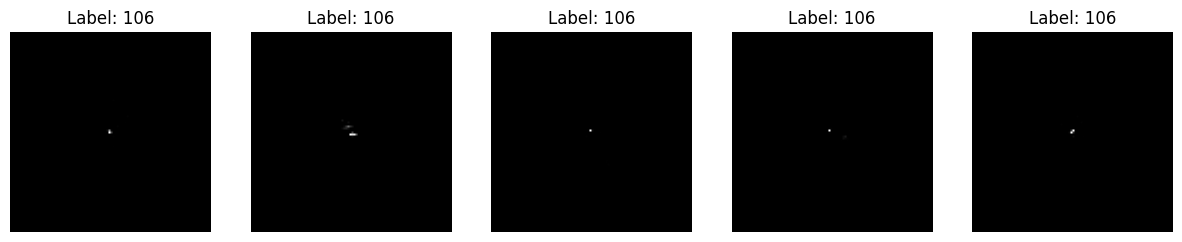

In [12]:
import matplotlib.pyplot as plt

# 1. Get a single batch from the generator
train_images_batch, train_labels_batch = next(train_gen)

# 2. Check the new shape (it should be 4-dimensional)
print(f"Shape of one batch of training images: {train_images_batch.shape}")
print(f"Shape of one batch of training labels: {train_labels_batch.shape}")

# 3. Visualize a few images from the batch
print("\nDisplaying a sample from the training set:")
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Use [:, :, 0] to select the single grayscale channel for plotting
    plt.imshow(train_images_batch[i, :, :, 0], cmap='gray') 
    plt.title(f"Label: {train_labels_batch[i][0]}")
    plt.axis('off')
plt.show()

Shape of one batch of validation images: (64, 100, 100, 1)
Shape of one batch of validation labels: (64,)

Displaying a sample from the validation set:


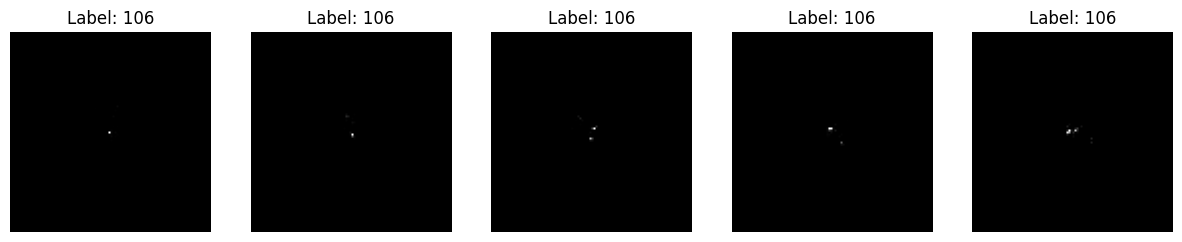

In [13]:
# 1. Get a single batch from the validation generator
validation_images_batch, validation_labels_batch = next(validation_gen)

# 2. Check the shape of the batch
print(f"Shape of one batch of validation images: {validation_images_batch.shape}")
print(f"Shape of one batch of validation labels: {validation_labels_batch.shape}")

# 3. Visualize a few images from the batch
print("\nDisplaying a sample from the validation set:")
plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Use [:, :, 0] to select the single grayscale channel
    plt.imshow(validation_images_batch[i, :, :, 0], cmap='gray')
    plt.title(f"Label: {validation_labels_batch[i][0]}")
    plt.axis('off')
plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA

# --- Parameters you already found ---
BEST_K_FOR_IMPUTER = 12
N_COMPONENTS = 13
missing_cols = [
    'j_tau3_b1_mmdt', 
    'j_tau3_b2_mmdt', 
    'j_tau32_b1_mmdt', 
    'j_tau32_b2_mmdt'
]
# ------------------------------------

# This code assumes your full 'train_df' (600k rows) and 'validation_df' are loaded
print("--- Preprocessing the full tabular dataset for model training ---")

# 1. Impute Missing Values on the full DataFrames
print("Step 1: Imputing missing values...")
train_df[missing_cols] = train_df[missing_cols].replace(0, np.nan)
validation_df[missing_cols] = validation_df[missing_cols].replace(0, np.nan)

imputer = KNNImputer(n_neighbors=BEST_K_FOR_IMPUTER)
scaler_for_impute = MinMaxScaler()

# Fit on the full training data and transform it
imputed_train = imputer.fit_transform(scaler_for_impute.fit_transform(train_df))
# Transform the full validation data
imputed_validation = imputer.transform(scaler_for_impute.transform(validation_df))

# 2. Scale for PCA
print("Step 2: Scaling data...")
scaler_for_pca = StandardScaler()
scaled_train_for_pca = scaler_for_pca.fit_transform(imputed_train)
scaled_validation_for_pca = scaler_for_pca.transform(imputed_validation)

# 3. Apply Final PCA
print("Step 3: Applying PCA...")
pca = PCA(n_components=N_COMPONENTS)
train_pca_full = pca.fit_transform(scaled_train_for_pca)
validation_pca_full = pca.transform(scaled_validation_for_pca)

print("\n--- Preprocessing of full dataset complete! ---")
print(f"Shape of new full training data: {train_pca_full.shape}")
print(f"Shape of training labels:      {train_labels.shape}")

--- Preprocessing the full tabular dataset for model training ---
Step 1: Imputing missing values...
Step 2: Scaling data...
Step 3: Applying PCA...

--- Preprocessing of full dataset complete! ---
Shape of new full training data: (260000, 13)
Shape of training labels:      (260000,)


In [15]:
from sklearn.preprocessing import LabelEncoder

# This assumes your 'train_labels' and 'validation_labels' are loaded

print("--- Encoding text labels into integers ---")
label_encoder = LabelEncoder()

# Fit on training labels and transform both sets
train_labels_encoded = label_encoder.fit_transform(train_labels.ravel())
validation_labels_encoded = label_encoder.transform(validation_labels.ravel())

print("Labels are now encoded and ready for the model.")

--- Encoding text labels into integers ---
Labels are now encoded and ready for the model.


In [16]:
!pip install catboost -q

from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cat_model = CatBoostClassifier(
    iterations=4375,
    verbose=200,
    random_state=42,
    early_stopping_rounds=50
)

print("\n--- Training CatBoost Model on Full Dataset ---")

print("\n--- Training CatBoost Model ---")
cat_model.fit(
    train_pca_full, 
    train_labels_encoded,  # Use the encoded labels
    eval_set=(validation_pca_full, validation_labels_encoded) # Use encoded labels
)


--- Training CatBoost Model on Full Dataset ---

--- Training CatBoost Model ---
Learning rate set to 0.068671
0:	learn: 1.5275078	test: 1.5272580	best: 1.5272580 (0)	total: 257ms	remaining: 18m 44s
200:	learn: 0.6667930	test: 0.6725845	best: 0.6725845 (200)	total: 23.6s	remaining: 8m 9s
400:	learn: 0.6136004	test: 0.6253715	best: 0.6253715 (400)	total: 45.5s	remaining: 7m 30s
600:	learn: 0.5881783	test: 0.6057940	best: 0.6057940 (600)	total: 1m 7s	remaining: 7m 3s
800:	learn: 0.5718600	test: 0.5948429	best: 0.5948429 (800)	total: 1m 29s	remaining: 6m 37s
1000:	learn: 0.5594676	test: 0.5879772	best: 0.5879772 (1000)	total: 1m 50s	remaining: 6m 12s
1200:	learn: 0.5497754	test: 0.5833270	best: 0.5833270 (1200)	total: 2m 12s	remaining: 5m 49s
1400:	learn: 0.5416145	test: 0.5801714	best: 0.5801714 (1400)	total: 2m 33s	remaining: 5m 26s
1600:	learn: 0.5342200	test: 0.5775574	best: 0.5775574 (1600)	total: 2m 55s	remaining: 5m 3s
1800:	learn: 0.5274023	test: 0.5755617	best: 0.5755617 (1800)	

--- Evaluating CatBoost Model on Validation Set ---

Accuracy: 0.8090

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.78      0.77     54410
           1       0.72      0.72      0.72     52420
           2       0.84      0.85      0.84     54617
           3       0.84      0.86      0.85     54243
           4       0.87      0.84      0.86     54310

    accuracy                           0.81    270000
   macro avg       0.81      0.81      0.81    270000
weighted avg       0.81      0.81      0.81    270000


Confusion Matrix:


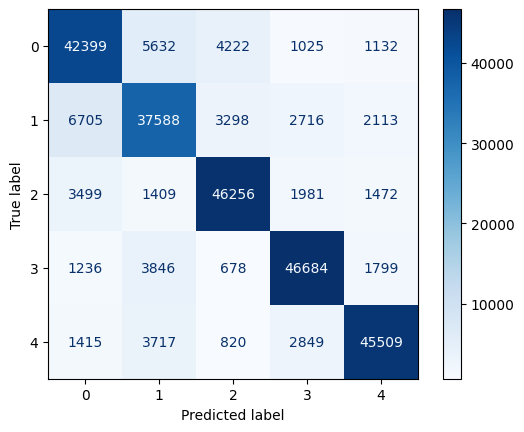

In [17]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# This code assumes you have these variables from the previous steps:
# cat_model: Your trained CatBoost model
# validation_pca_full: Your preprocessed validation features
# validation_labels_encoded: Your numerically encoded validation labels

print("--- Evaluating CatBoost Model on Validation Set ---")

# 1. Get predictions on the validation data
y_pred = cat_model.predict(validation_pca_full)

# 2. Calculate and print the accuracy
accuracy = accuracy_score(validation_labels_encoded, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# 3. Print the full classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(validation_labels_encoded, y_pred))

# 4. Display the confusion matrix
print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_estimator(cat_model, validation_pca_full, validation_labels_encoded, cmap='Blues')
plt.show()

In [18]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

# Initialize the LightGBM model
lgb_model = LGBMClassifier(
    n_estimators=1000,      # Build up to 1000 trees
    random_state=42
)

print("--- Training LightGBM Model ---")

# Train the model with early stopping
# This will stop training if the validation loss doesn't improve for 50 consecutive rounds.
lgb_model.fit(
    train_pca_full,
    train_labels_encoded,
    eval_set=[(validation_pca_full, validation_labels_encoded)],
    callbacks=[lgb.early_stopping(50, verbose=True)]
)

--- Training LightGBM Model ---
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006497 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3315
[LightGBM] [Info] Number of data points in the train set: 260000, number of used features: 13
[LightGBM] [Info] Start training from score -1.603379
[LightGBM] [Info] Start training from score -1.638095
[LightGBM] [Info] Start training from score -1.600173
[LightGBM] [Info] Start training from score -1.599050
[LightGBM] [Info] Start training from score -1.607018
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[842]	valid_0's multi_logloss: 0.578617


LGBMClassifier(n_estimators=1000, random_state=42)


--- Evaluating LightGBM Model on Validation Set ---

Accuracy: 0.8035

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.78      0.77     54410
           1       0.71      0.72      0.71     52420
           2       0.84      0.84      0.84     54617
           3       0.84      0.85      0.85     54243
           4       0.87      0.83      0.85     54310

    accuracy                           0.80    270000
   macro avg       0.80      0.80      0.80    270000
weighted avg       0.80      0.80      0.80    270000


Confusion Matrix:


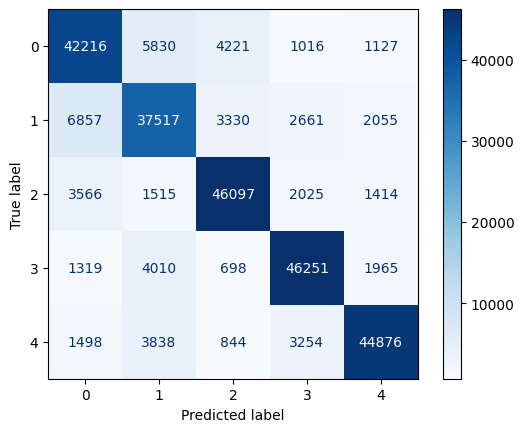

In [19]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\n--- Evaluating LightGBM Model on Validation Set ---")

# Get predictions on the validation data
y_pred = lgb_model.predict(validation_pca_full)

# Calculate and print the accuracy
accuracy = accuracy_score(validation_labels_encoded, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Print the full classification report
print("\nClassification Report:")
print(classification_report(validation_labels_encoded, y_pred))

# Display the confusion matrix
print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_estimator(lgb_model, validation_pca_full, validation_labels_encoded, cmap='Blues')
plt.show()

In [20]:
from xgboost import XGBClassifier

# Initialize the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=1000,             # Build up to 1000 trees
    use_label_encoder=False,       # A setting to avoid a deprecation warning
    eval_metric='mlogloss',        # Logloss for multi-class classification
    random_state=42
)

print("--- Training XGBoost Model ---")

# Train the model with early stopping
xgb_model.fit(
    train_pca_full,
    train_labels_encoded,
    eval_set=[(validation_pca_full, validation_labels_encoded)],
    early_stopping_rounds=50, # Stop if validation loss doesn't improve for 50 rounds
    verbose=100               # Print progress every 100 rounds
)

--- Training XGBoost Model ---


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


[0]	validation_0-mlogloss:1.32422
[100]	validation_0-mlogloss:0.59366
[200]	validation_0-mlogloss:0.58299
[276]	validation_0-mlogloss:0.58257


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)


--- Evaluating XGBoost Model on Validation Set ---

Accuracy: 0.8024

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77     54410
           1       0.71      0.71      0.71     52420
           2       0.83      0.84      0.84     54617
           3       0.84      0.85      0.84     54243
           4       0.87      0.83      0.85     54310

    accuracy                           0.80    270000
   macro avg       0.80      0.80      0.80    270000
weighted avg       0.80      0.80      0.80    270000


Confusion Matrix:


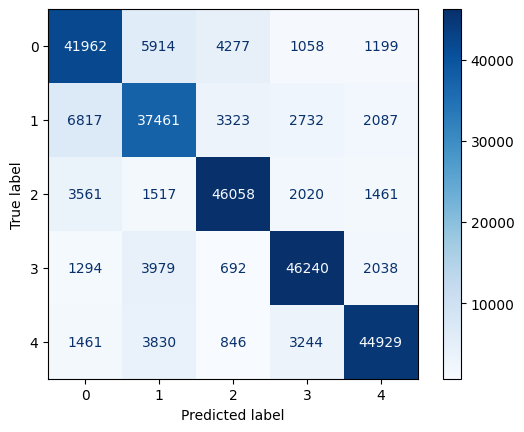

In [21]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\n--- Evaluating XGBoost Model on Validation Set ---")

# Get predictions on the validation data
y_pred = xgb_model.predict(validation_pca_full)

# Calculate and print the accuracy
accuracy = accuracy_score(validation_labels_encoded, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Print the full classification report
print("\nClassification Report:")
print(classification_report(validation_labels_encoded, y_pred))

# Display the confusion matrix
print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_estimator(xgb_model, validation_pca_full, validation_labels_encoded, cmap='Blues')
plt.show()

In [22]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=1000,      # Number of trees in the forest
    random_state=42,       # For reproducibility
    n_jobs=-1              # Use all available CPU cores to speed up training
)

print("--- Training Random Forest Model ---")

# Train the model
# Note: RandomForestClassifier's .fit() method is simpler than the boosting models;
# it doesn't use an eval_set or early stopping rounds.
rf_model.fit(train_pca_full, train_labels_encoded)

print("Training complete.")

--- Training Random Forest Model ---
Training complete.



--- Evaluating Random Forest Model on Validation Set ---

Accuracy: 0.8000

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.78      0.76     54410
           1       0.71      0.71      0.71     52420
           2       0.83      0.85      0.84     54617
           3       0.84      0.84      0.84     54243
           4       0.87      0.82      0.84     54310

    accuracy                           0.80    270000
   macro avg       0.80      0.80      0.80    270000
weighted avg       0.80      0.80      0.80    270000


Confusion Matrix:


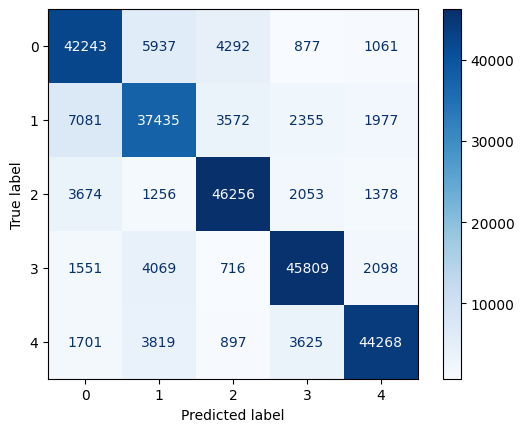

In [23]:
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("\n--- Evaluating Random Forest Model on Validation Set ---")

# Get predictions on the validation data
y_pred = rf_model.predict(validation_pca_full)

# Calculate and print the accuracy
accuracy = accuracy_score(validation_labels_encoded, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Print the full classification report
print("\nClassification Report:")
print(classification_report(validation_labels_encoded, y_pred))

# Display the confusion matrix
print("\nConfusion Matrix:")
ConfusionMatrixDisplay.from_estimator(rf_model, validation_pca_full, validation_labels_encoded, cmap='Blues')
plt.show()

In [24]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# This code assumes you have the following trained models and data:
# cat_model, lgb_model, xgb_model, rf_model
# validation_pca_full, validation_labels_encoded

print("--- Creating Ensemble Predictions using Soft Voting ---")

# 1. Get the prediction probabilities from each model
print("Getting probabilities from each model...")
probs_cat = cat_model.predict_proba(validation_pca_full)
probs_lgb = lgb_model.predict_proba(validation_pca_full)
probs_xgb = xgb_model.predict_proba(validation_pca_full)
probs_rf = rf_model.predict_proba(validation_pca_full)

# 2. Average the probabilities
# Here we're ensembling four models.
print("Averaging the probabilities...")
average_probs = (probs_cat + probs_lgb + probs_xgb + probs_rf) / 4.0

# 3. Get the final class prediction
# Find the class with the highest average probability for each sample
ensemble_preds = np.argmax(average_probs, axis=1)

# 4. Evaluate the ensemble's performance
print("\n--- Evaluating Ensemble Performance ---")
accuracy = accuracy_score(validation_labels_encoded, ensemble_preds)
print(f"\nEnsemble Accuracy: {accuracy:.4f}")

# Compare to your best single model (CatBoost)
print(f"Best Single Model (CatBoost) Accuracy: 0.8060")
if accuracy > 0.8060:
    print("✅ Ensemble model has improved the accuracy!")
else:
    print("❌ Ensemble model did not improve accuracy this time.")


print("\nEnsemble Classification Report:")
print(classification_report(validation_labels_encoded, ensemble_preds))

--- Creating Ensemble Predictions using Soft Voting ---
Getting probabilities from each model...
Averaging the probabilities...

--- Evaluating Ensemble Performance ---

Ensemble Accuracy: 0.8081
Best Single Model (CatBoost) Accuracy: 0.8060
✅ Ensemble model has improved the accuracy!

Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.78      0.77     54410
           1       0.72      0.72      0.72     52420
           2       0.84      0.85      0.84     54617
           3       0.84      0.86      0.85     54243
           4       0.88      0.83      0.85     54310

    accuracy                           0.81    270000
   macro avg       0.81      0.81      0.81    270000
weighted avg       0.81      0.81      0.81    270000




Ensemble Confusion Matrix:


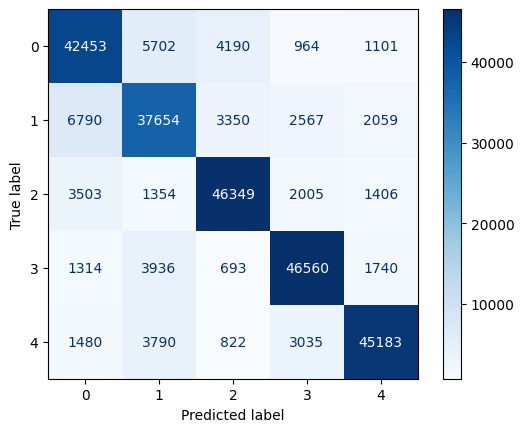

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
print("\nEnsemble Confusion Matrix:")

# Create and display the confusion matrix from the predictions
ConfusionMatrixDisplay.from_predictions(
    y_true=validation_labels_encoded, 
    y_pred=ensemble_preds, 
    cmap='Blues'
)
plt.show()